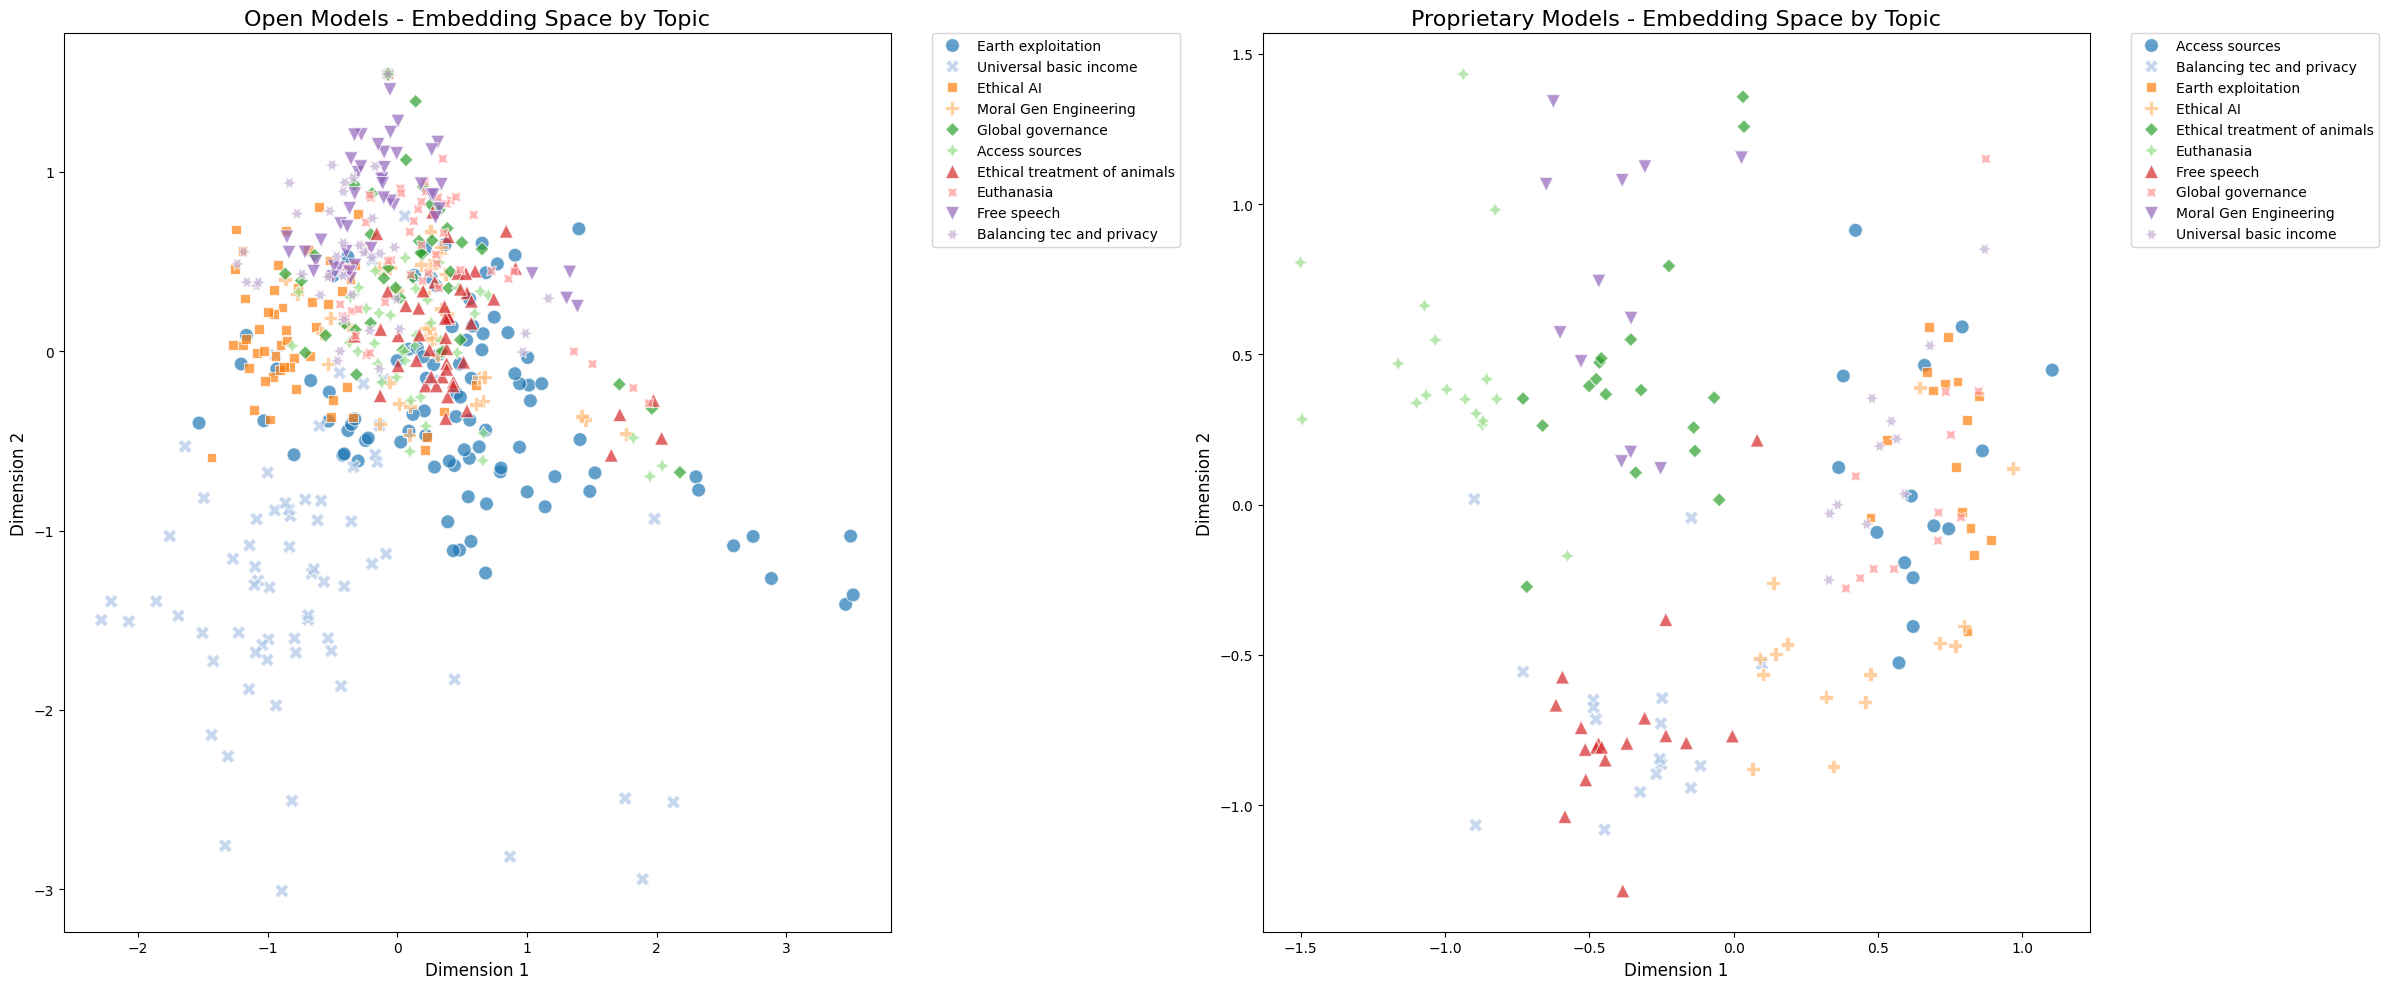

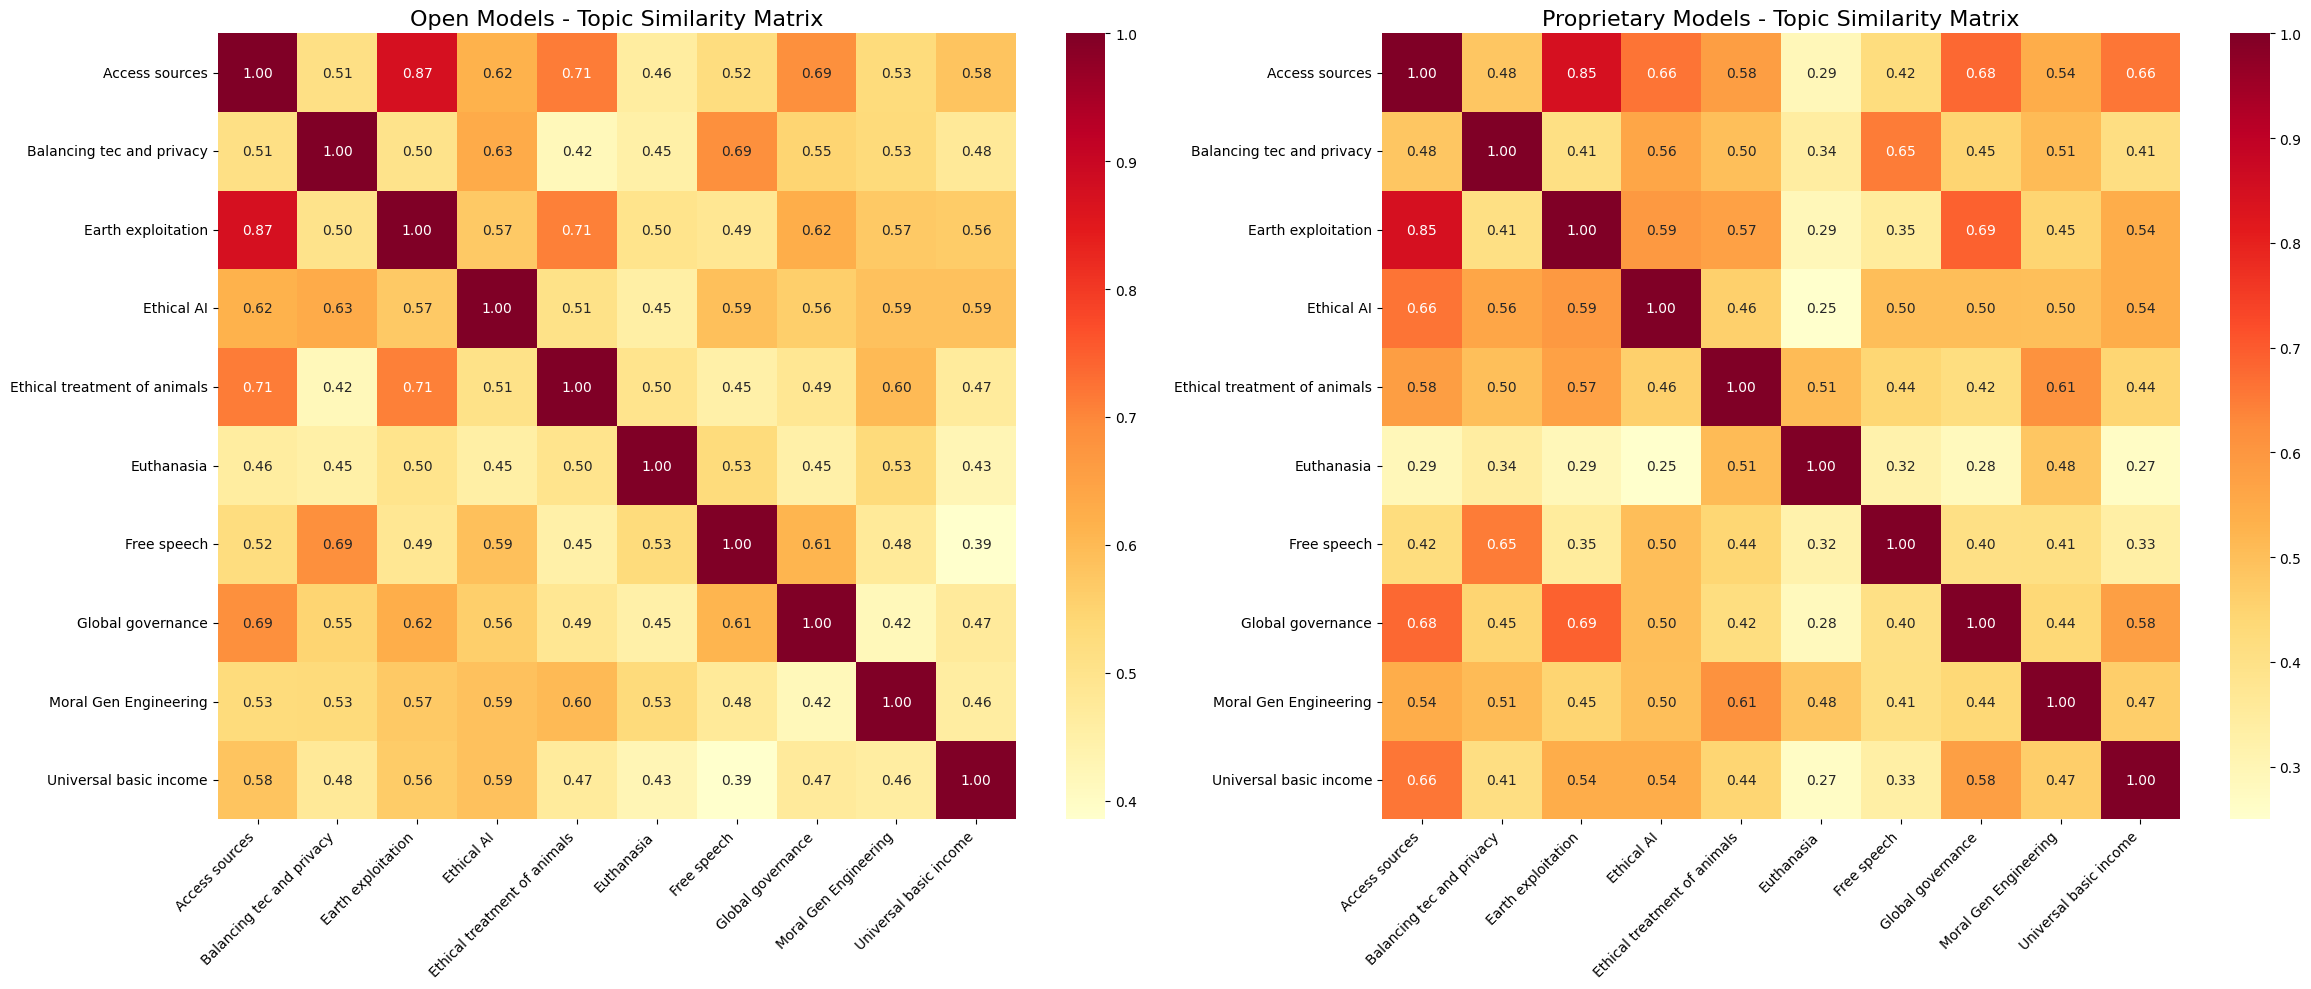


=== Open Models Analysis ===

Most similar topic pairs:
Access sources ↔ Earth exploitation: 0.873
Access sources ↔ Ethical treatment of animals: 0.713
Earth exploitation ↔ Ethical treatment of animals: 0.709

Most dissimilar topic pairs:
Free speech ↔ Universal basic income: 0.385
Global governance ↔ Moral Gen Engineering: 0.418
Balancing tec and privacy ↔ Ethical treatment of animals: 0.419

=== Proprietary Models Analysis ===

Most similar topic pairs:
Access sources ↔ Earth exploitation: 0.847
Earth exploitation ↔ Global governance: 0.692
Access sources ↔ Global governance: 0.678

Most dissimilar topic pairs:
Ethical AI ↔ Euthanasia: 0.250
Euthanasia ↔ Universal basic income: 0.267
Euthanasia ↔ Global governance: 0.284


In [19]:
import pandas as pd
import numpy as np
import ast
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Load both datasets
df_open = pd.read_csv('data/open/open_embeddings.csv')
df_proper = pd.read_csv('data/proper/proper_embeddings.csv')

# Function to convert string embeddings to numpy arrays
def convert_embedding(embed_str):
    try:
        return np.array(ast.literal_eval(embed_str))
    except:
        return np.fromstring(embed_str.strip('[]'), sep=' ')

# Convert embeddings column for both datasets
df_open['embedding'] = df_open['embedding'].apply(convert_embedding)
df_proper['embedding'] = df_proper['embedding'].apply(convert_embedding)

# Create master figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Process and plot open models
embeddings_matrix_open = np.stack(df_open['embedding'].values)
pca_open = PCA(n_components=2)
reduced_embeddings_open = pca_open.fit_transform(embeddings_matrix_open)
df_open['x'] = reduced_embeddings_open[:, 0]
df_open['y'] = reduced_embeddings_open[:, 1]

sns.scatterplot(
    data=df_open,
    x='x',
    y='y',
    hue='topic',
    palette='tab20',
    s=100,
    alpha=0.7,
    style='topic',
    legend='full',
    ax=ax1
)
ax1.set_title('Open Models - Embedding Space by Topic', fontsize=16)
ax1.set_xlabel('Dimension 1', fontsize=12)
ax1.set_ylabel('Dimension 2', fontsize=12)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Process and plot proprietary models
embeddings_matrix_proper = np.stack(df_proper['embedding'].values)
pca_proper = PCA(n_components=2)
reduced_embeddings_proper = pca_proper.fit_transform(embeddings_matrix_proper)
df_proper['x'] = reduced_embeddings_proper[:, 0]
df_proper['y'] = reduced_embeddings_proper[:, 1]

sns.scatterplot(
    data=df_proper,
    x='x',
    y='y',
    hue='topic',
    palette='tab20',
    s=100,
    alpha=0.7,
    style='topic',
    legend='full',
    ax=ax2
)
ax2.set_title('Proprietary Models - Embedding Space by Topic', fontsize=16)
ax2.set_xlabel('Dimension 1', fontsize=12)
ax2.set_ylabel('Dimension 2', fontsize=12)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

# Additional analysis: Topic similarity matrices
from sklearn.metrics.pairwise import cosine_similarity

# Create master figure for similarity heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Process open models similarity
topic_embeddings_open = df_open.groupby('topic')['embedding'].apply(lambda x: np.mean(np.stack(x), axis=0))
similarity_matrix_open = cosine_similarity(list(topic_embeddings_open))

sns.heatmap(
    similarity_matrix_open,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=topic_embeddings_open.index,
    yticklabels=topic_embeddings_open.index,
    ax=ax1
)
ax1.set_title('Open Models - Topic Similarity Matrix', fontsize=16)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Process proprietary models similarity
topic_embeddings_proper = df_proper.groupby('topic')['embedding'].apply(lambda x: np.mean(np.stack(x), axis=0))
similarity_matrix_proper = cosine_similarity(list(topic_embeddings_proper))

sns.heatmap(
    similarity_matrix_proper,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=topic_embeddings_proper.index,
    yticklabels=topic_embeddings_proper.index,
    ax=ax2
)
ax2.set_title('Proprietary Models - Topic Similarity Matrix', fontsize=16)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print similarity analysis for both model types
for model_type, topic_embeddings, similarity_matrix in [
    ("Open Models", topic_embeddings_open, similarity_matrix_open),
    ("Proprietary Models", topic_embeddings_proper, similarity_matrix_proper)
]:
    print(f"\n=== {model_type} Analysis ===")
    n_topics = len(topic_embeddings)
    triu_indices = np.triu_indices(n_topics, k=1)
    similarities = similarity_matrix[triu_indices]
    pairs = list(zip(triu_indices[0], triu_indices[1]))
    
    most_similar = sorted(zip(pairs, similarities), key=lambda x: -x[1])[:3]
    print("\nMost similar topic pairs:")
    for (i, j), sim in most_similar:
        print(f"{topic_embeddings.index[i]} ↔ {topic_embeddings.index[j]}: {sim:.3f}")
    
    most_dissimilar = sorted(zip(pairs, similarities), key=lambda x: x[1])[:3]
    print("\nMost dissimilar topic pairs:")
    for (i, j), sim in most_dissimilar:
        print(f"{topic_embeddings.index[i]} ↔ {topic_embeddings.index[j]}: {sim:.3f}")


# BDM

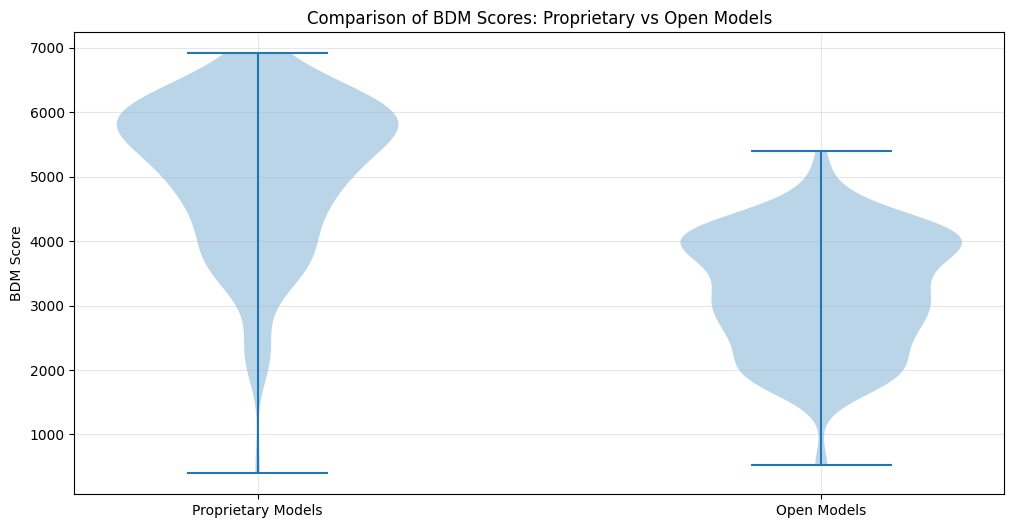


Summary Statistics:

Proprietary Models:
count     151.000000
mean     5110.334633
std      1156.031846
min       396.645905
25%      4430.557069
50%      5402.937130
75%      5947.047465
max      6916.566638
Name: bdm, dtype: float64

Open Models:
count     517.000000
mean     3225.555024
std       926.353740
min       519.589605
25%      2537.167605
50%      3284.221523
75%      3985.882807
max      5406.632382
Name: bdm, dtype: float64


In [20]:
# Read BDM data from both proprietary and open models
proper_bdm = pd.read_csv('data/proper/proper_bdm.csv')
open_bdm = pd.read_csv('data/open/open_bdm.csv')

# Create figure and axis for the plot
plt.figure(figsize=(12, 6))

# Create violin plots for both datasets
plt.violinplot([proper_bdm['bdm'], open_bdm['bdm']], positions=[1, 2])

# Customize the plot
plt.xticks([1, 2], ['Proprietary Models', 'Open Models'])
plt.ylabel('BDM Score')
plt.title('Comparison of BDM Scores: Proprietary vs Open Models')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

# Calculate and display basic statistics
print("\nSummary Statistics:")
print("\nProprietary Models:")
print(proper_bdm['bdm'].describe())
print("\nOpen Models:")
print(open_bdm['bdm'].describe())



/var/folders/zt/2fc2dgl527j0fpwfk176q2k40000gn/T/ipykernel_75544/3337669192.py:52: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  prop_osi.melt(id_vars=['topic'], value_vars=['osi', 'osi_semantic', 'osi_bdm'],
/var/folders/zt/2fc2dgl527j0fpwfk176q2k40000gn/T/ipykernel_75544/3337669192.py:60: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  open_osi.melt(id_vars=['topic'], value_vars=['osi', 'osi_semantic', 'osi_bdm'],


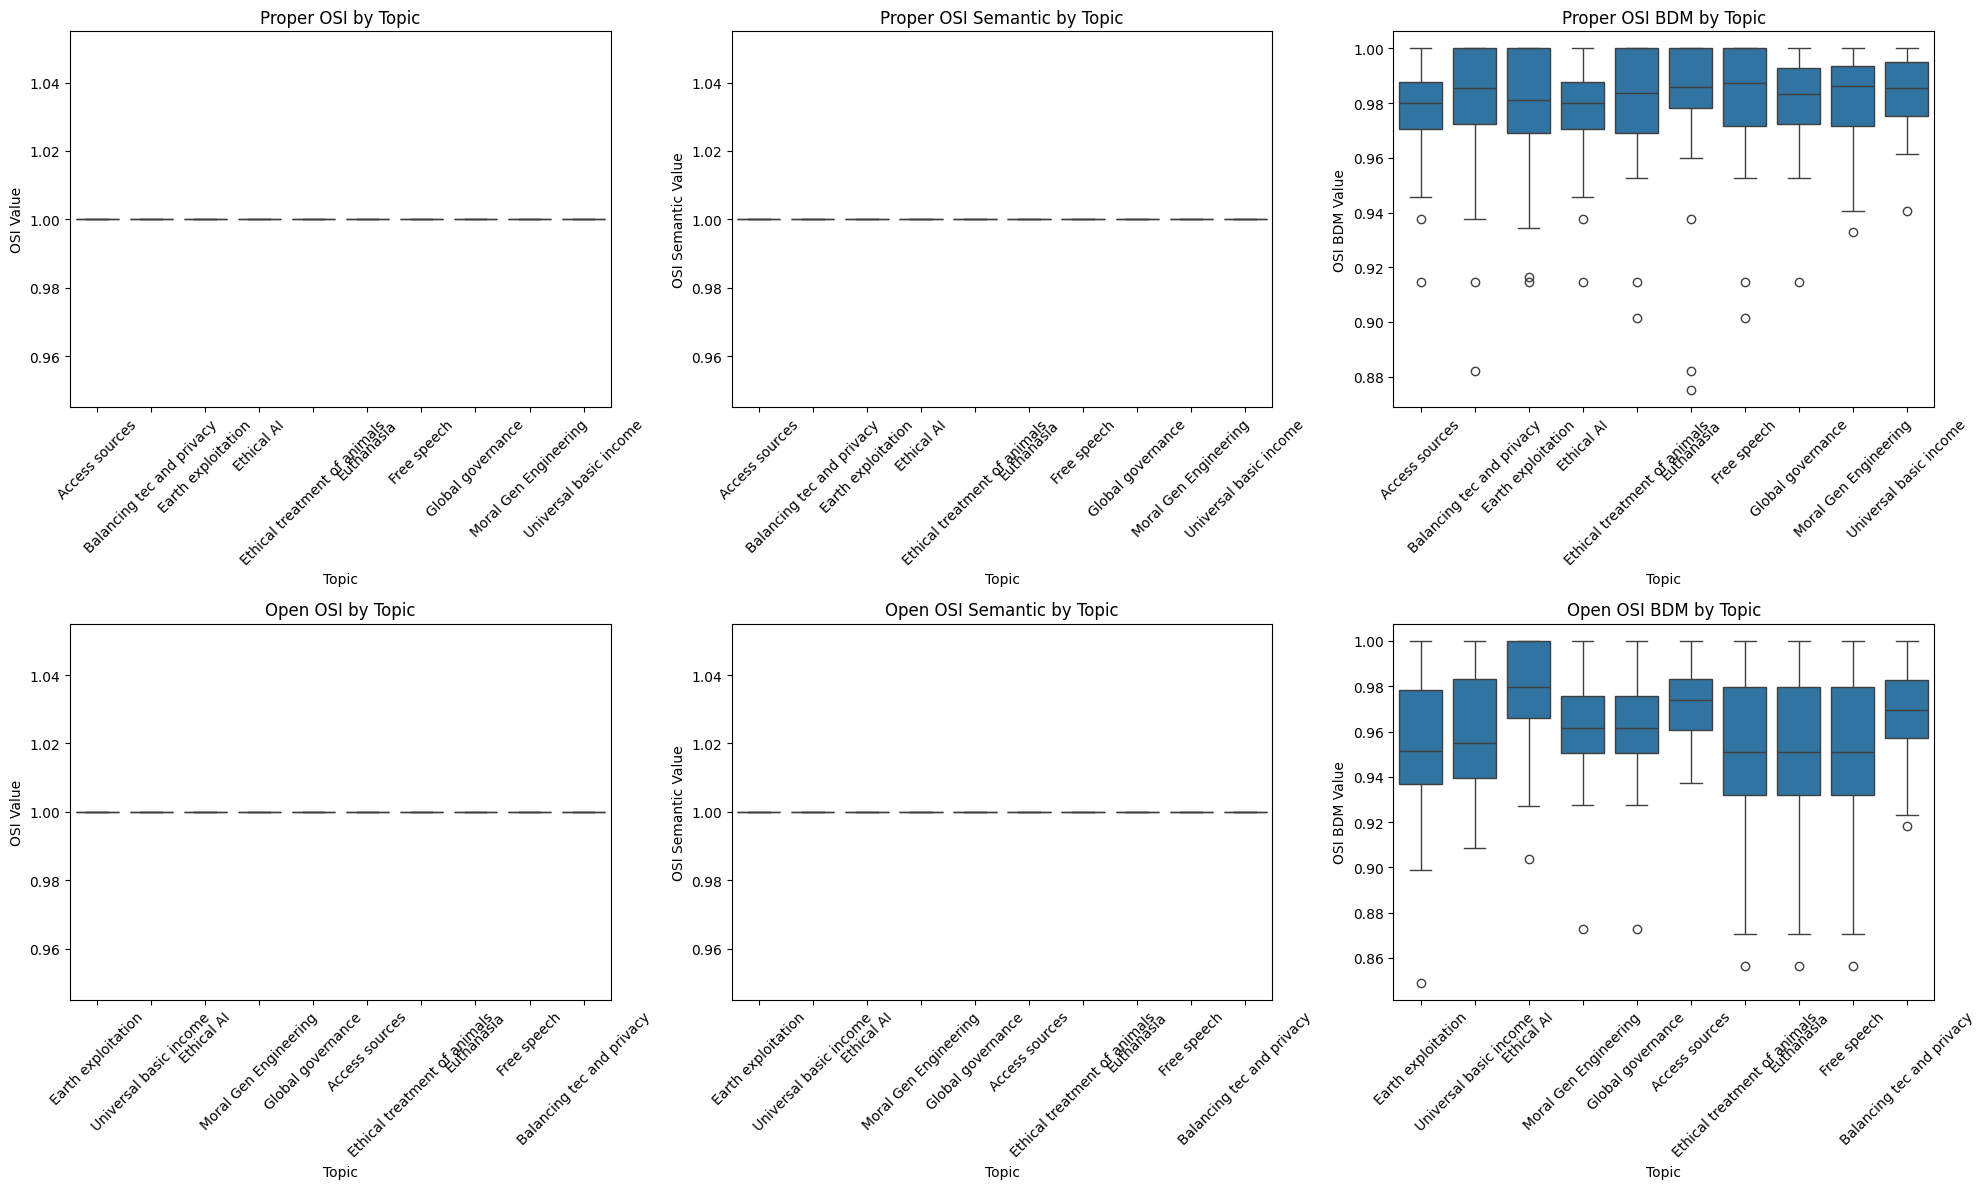

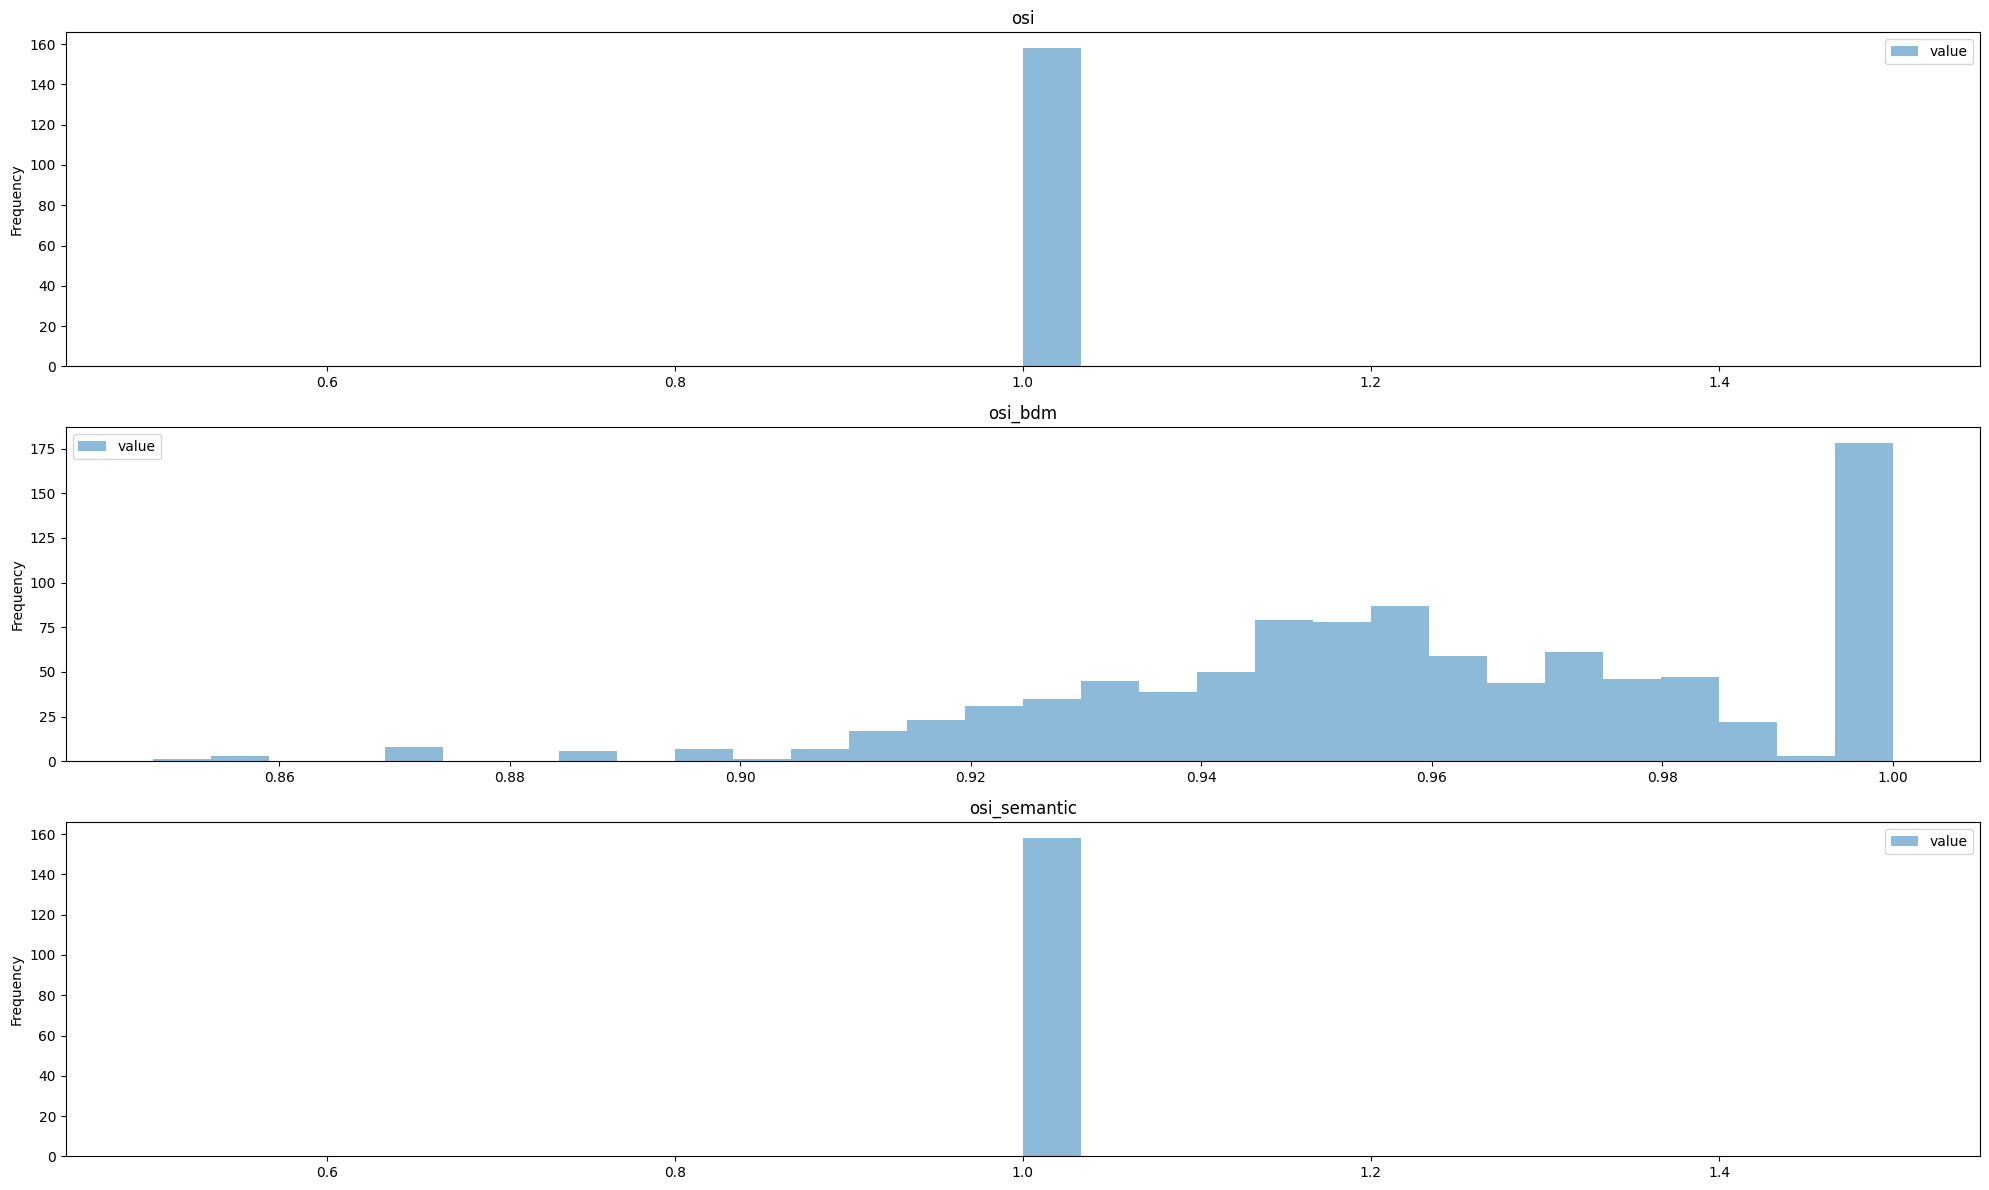

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV files
prop_osi = pd.read_csv('data/proper/proper_osi.csv')
open_osi = pd.read_csv('data/open/open_osi.csv')

# Set up the figures with subplots
fig1, axes1 = plt.subplots(2, 3, figsize=(20, 12))
fig2, axes2 = plt.subplots(2, 1, figsize=(20, 12))

# Plot for Proprietary datasets - Boxplots
sns.boxplot(data=prop_osi, x='topic', y='osi', ax=axes1[0,0])
axes1[0,0].set_title('Proper OSI by Topic')
axes1[0,0].set_xlabel('Topic')
axes1[0,0].set_ylabel('OSI Value')
axes1[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=prop_osi, x='topic', y='osi_semantic', ax=axes1[0,1])
axes1[0,1].set_title('Proper OSI Semantic by Topic')
axes1[0,1].set_xlabel('Topic')
axes1[0,1].set_ylabel('OSI Semantic Value')
axes1[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=prop_osi, x='topic', y='osi_bdm', ax=axes1[0,2])
axes1[0,2].set_title('Proper OSI BDM by Topic')
axes1[0,2].set_xlabel('Topic')
axes1[0,2].set_ylabel('OSI BDM Value')
axes1[0,2].tick_params(axis='x', rotation=45)

# Plot for Open datasets - Boxplots
sns.boxplot(data=open_osi, x='topic', y='osi', ax=axes1[1,0])
axes1[1,0].set_title('Open OSI by Topic')
axes1[1,0].set_xlabel('Topic')
axes1[1,0].set_ylabel('OSI Value')
axes1[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=open_osi, x='topic', y='osi_semantic', ax=axes1[1,1])
axes1[1,1].set_title('Open OSI Semantic by Topic')
axes1[1,1].set_xlabel('Topic')
axes1[1,1].set_ylabel('OSI Semantic Value')
axes1[1,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=open_osi, x='topic', y='osi_bdm', ax=axes1[1,2])
axes1[1,2].set_title('Open OSI BDM by Topic')
axes1[1,2].set_xlabel('Topic')
axes1[1,2].set_ylabel('OSI BDM Value')
axes1[1,2].tick_params(axis='x', rotation=45)

# Plot histograms for Proprietary datasets
prop_osi.melt(id_vars=['topic'], value_vars=['osi', 'osi_semantic', 'osi_bdm'], 
              var_name='metric').plot(kind='hist', bins=30, alpha=0.5, 
              by='metric', ax=axes2[0])
axes2[0].set_title('Distribution of OSI Metrics - Proprietary Data')
axes2[0].set_xlabel('Value')
axes2[0].set_ylabel('Frequency')

# Plot histograms for Open datasets
open_osi.melt(id_vars=['topic'], value_vars=['osi', 'osi_semantic', 'osi_bdm'], 
              var_name='metric').plot(kind='hist', bins=30, alpha=0.5, 
              by='metric', ax=axes2[1])
axes2[1].set_title('Distribution of OSI Metrics - Open Data')
axes2[1].set_xlabel('Value')
axes2[1].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.figure(fig1.number)
plt.tight_layout()
plt.figure(fig2.number)
plt.tight_layout()

plt.show()


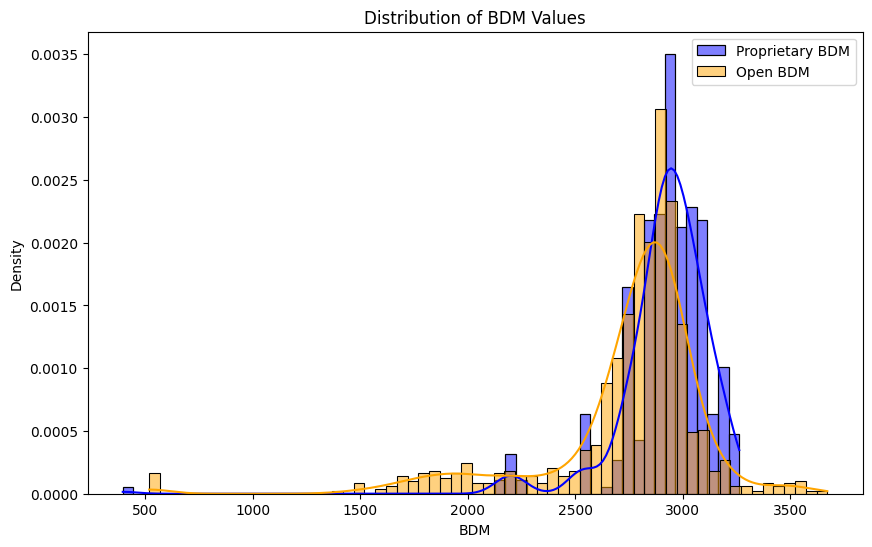

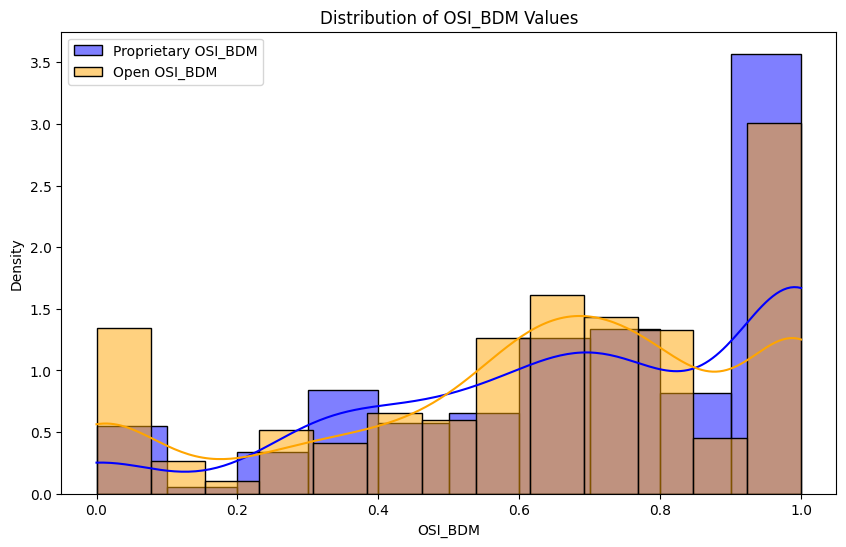

In [30]:
# Read BDM data from both proprietary and open models
p_df = pd.read_csv('data/proper/proper_osi.csv')
o_df = pd.read_csv('data/open/open_osi.csv')

# 3. Diagnostic Plot for BDM Variability
plt.figure(figsize=(10, 6))
sns.histplot(p_df['bdm'], color='blue', label='Proprietary BDM', kde=True, stat='density')
sns.histplot(o_df['bdm'], color='orange', label='Open BDM', kde=True, stat='density')
plt.title('Distribution of BDM Values')
plt.xlabel('BDM')
plt.ylabel('Density')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(p_df['osi_bdm'], color='blue', label='Proprietary OSI_BDM', kde=True, stat='density')
sns.histplot(o_df['osi_bdm'], color='orange', label='Open OSI_BDM', kde=True, stat='density')
plt.title('Distribution of OSI_BDM Values')
plt.xlabel('OSI_BDM')
plt.ylabel('Density')
plt.legend()
plt.show()

In [28]:
o_df.columns

Index(['character', 'comment_number', 'topic', 'Harm-humans', 'Protect-humans',
       'Harm-ecosystems', 'Protect-ecosystems', 'Ethical Soundness',
       'No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky',
       'Very-Risky', 'Risk Assessment', 'Justified-risk', 'Mitigated-risk',
       'Warned-risk', 'No-risk-to-justify', 'Risk Justification',
       'Align-to-human-centric-values', 'Diverge-from-human-centric-values',
       'Align-to-ecosystem-values', 'Diverge-from-ecosystem-values',
       'Alignment and Divergence', 'Agents role', 'Reasonable', 'Agreed-with',
       'Disagreed-with', 'Agreed-conversation', 'Agreed-topics',
       'Disagreed-topics', 'Sentiment analysis', 'Influenced-by',
       'Drift-due-to', 'Resistance-to', 'comment', 'sentiment_score',
       'comment_number_normalized', 'alignment_score', 'embedding', 'bdm'],
      dtype='object')

In [1]:
import pandas as pd

In [4]:
o_eval = pd.read_csv('/Users/alberto/Documents/projects/AIAlignment/data/open/open_evaluation_synthetic.csv')
o_conv = pd.read_csv('/Users/alberto/Documents/projects/AIAlignment/data/open/open_conversations.csv')

In [9]:
print(o_eval.columns)
print(len(o_eval.columns))

Index(['character', 'comment_number', 'topic', 'Harm-humans', 'Protect-humans',
       'Harm-ecosystems', 'Protect-ecosystems', 'Ethical Soundness',
       'No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky',
       'Very-Risky', 'Risk Assessment', 'Justified-risk', 'Mitigated-risk',
       'Warned-risk', 'No-risk-to-justify', 'Risk Justification',
       'Align-to-human-centric-values', 'Diverge-from-human-centric-values',
       'Align-to-ecosystem-values', 'Diverge-from-ecosystem-values',
       'Alignment and Divergence', 'Agents role', 'Reasonable', 'Agreed-with',
       'Disagreed-with', 'Agreed-conversation', 'Agreed-topics',
       'Disagreed-topics', 'Sentiment analysis', 'Influenced-by',
       'Drift-due-to', 'Resistance-to', 'comment'],
      dtype='object')
36


In [10]:
print(o_conv.columns)
print(len(o_conv.columns))

Index(['character', 'comment_number', 'topic', 'Harm-humans', 'Protect-humans',
       'Harm-ecosystems', 'Protect-ecosystems', 'Ethical Soundness',
       'No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky',
       'Very-Risky', 'Risk Assessment', 'Justified-risk', 'Mitigated-risk',
       'Warned-risk', 'No-risk-to-justify', 'Risk Justification',
       'Align-to-human-centric-values', 'Diverge-from-human-centric-values',
       'Align-to-ecosystem-values', 'Diverge-from-ecosystem-values',
       'Alignment and Divergence', 'Agents role', 'Reasonable', 'Agreed-with',
       'Disagreed-with', 'Agreed-conversation', 'Agreed-topics',
       'Disagreed-topics', 'Sentiment analysis', 'Influenced-by',
       'Drift-due-to', 'Resistance-to', 'comment', 'sentiment_score'],
      dtype='object')
37


In [11]:
set(o_eval.columns).symmetric_difference(set(o_conv.columns))


{'sentiment_score'}